In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
X=df[['displacement']]
y=df['mpg']

print("Missing values in ",X.isnull().sum())
print("Missing values: ",y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values:  0


In [4]:
data = df[['displacement','mpg']].dropna()

X = data[['displacement']]
y = data['mpg']
print("features:")
print(X.head())
print("target:")
print(y.head())


features:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0
target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
print("Training Samples: ",len(X_train))
print("Testing Samples: ",len(X_test))

Training Samples:  318
Testing Samples:  80


In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test,y_pred_linear)
r2_linear = r2_score(y_test,y_pred_linear)
print("Linear regression")
print("-----------------")
print("MSE: ",mse_linear)
print("R2 Score: ",r2_linear)

Linear regression
-----------------
MSE:  18.102543998358946
R2 Score:  0.6633114869465595


In [7]:
results = []

poly_models = {}

results.append({
    'Model' : 'Linear Regression',
    'Degree' : 1,
    'MSE' : mse_linear,
    'R2 Score' : r2_linear
})


In [8]:
results = []
polynomial_models = {}   

for degree in range(2, 6):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    mse_poly = mean_squared_error(y_test, y_pred_poly)
    r2_poly = r2_score(y_test, y_pred_poly)

    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse_poly,
        'R2 Score': r2_poly
    })

    polynomial_models[degree] = {
        'Poly': poly,
        'Model': poly_model
    }

In [9]:
results_df = pd.DataFrame(results)
results_df

,Model,Degree,MSE,R2 Score
0,Polynomial Regression,2,15.107354,0.719019
1,Polynomial Regression,3,14.943632,0.722064
2,Polynomial Regression,4,14.961487,0.721732
3,Polynomial Regression,5,15.230896,0.716721


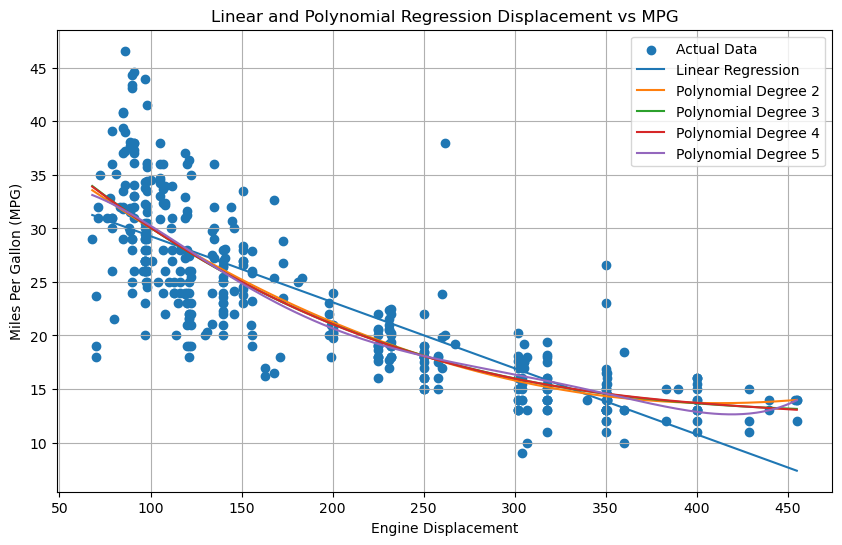

In [10]:
X_plot = pd.DataFrame ({
    'displacement' : np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

plt.figure(figsize=(10,6))
plt.scatter(
    X['displacement'],
    y,
    label = 'Actual Data'
)

y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label = 'Linear Regression'
)

for degree in range(2, 6): 
    poly = polynomial_models[degree]['Poly'] 
    poly_model = polynomial_models[degree]['Model'] 
    
    X_plot_poly = poly.transform(X_plot) 
    y_plot_poly = poly_model.predict(X_plot_poly) 
    plt.plot( X_plot['displacement'], 
              y_plot_poly, 
              label = f'Polynomial Degree {degree}' 
    ) 
    plt.xlabel('Engine Displacement') 
    plt.ylabel('Miles Per Gallon (MPG)')
    plt.title('Linear and Polynomial Regression Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

    

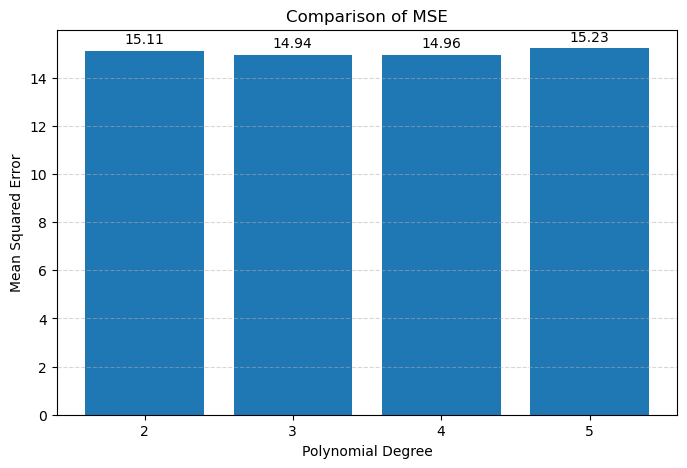

In [11]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),results_df['MSE']
)
plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)

plt.show()

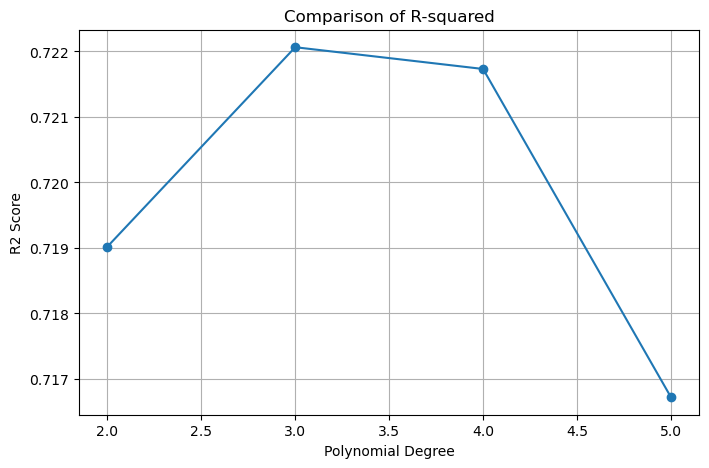

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R2 Score'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()

    
    